docker run --volume C:/Users/jack/local/colab:/data -p 127.0.0.1:9000:8080 us-docker.pkg.dev/colab-images/public/cpu-runtime

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
%%bash
if ! python3 -c 'import neurokit2' &> /dev/null; then
    echo "Installing neurokit2..."
    pip3 install neurokit2 > /dev/null
else
    echo "neurokit2 already installed"
fi

neurokit2 already installed


In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from datasets import load_dataset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import neurokit2 as nk
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler
from huggingface_hub import notebook_login
from joblib import Parallel, delayed
notebook_login()

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

CONSTANTS

In [ ]:
# DIR_PATH = '/content/drive/MyDrive/ENEE408N/ENEE408N Project/sample of DREAMT dataset'
DIR_PATH = '/data'

PPG_LABELED_FILE_TRAIN = os.path.join(DIR_PATH, 'unbal_all_ppg_labeled_train.csv')
PPG_LABELED_FILE_TEST = os.path.join(DIR_PATH, 'unbal_all_ppg_labeled_test.csv')
PPG_FILE_TRAIN_FEAT_EXTR = os.path.join(DIR_PATH, 'unbal_all_ppg_feat_extr_train.csv')
PPG_FILE_TEST_FEAT_EXTR = os.path.join(DIR_PATH, 'unbal_all_ppg_feat_extr_test.csv')

SEG_DUR_SEC= 10
FS = 64
SAMPLES_PER_SEG = SEG_DUR_SEC * FS

a = np.arange(2, 103+1)
TRAIN_IDS = a[(a % 5 != 0) & (a != 41)]
TEST_IDS = a[(a % 5 == 0) & (a != 60)]

# TRAIN_IDS = [53, 54, 56, 57, 58]  #, 59, 63, 62]
# TEST_IDS = [55]     #, 61]

FIELDS_OF_INTEREST = ['TIMESTAMP', 'BVP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'Sleep_Stage', 'Obstructive_Apnea', 'Central_Apnea', 'Hypopnea']

Load Dreamt dataset

In [ ]:
ids = np.hstack([TRAIN_IDS, TEST_IDS])
data_files = dict(zip(ids, [f'data_64Hz/S{n:03}_whole_df.csv' for n in ids]))

dreamt = load_dataset('bsaenz/dreamt', data_files=data_files)

data_64Hz/S008_whole_df.csv:   0%|          | 0.00/142M [00:00<?, ?B/s]

data_64Hz/S009_whole_df.csv:   0%|          | 0.00/137M [00:00<?, ?B/s]

data_64Hz/S011_whole_df.csv:   0%|          | 0.00/143M [00:00<?, ?B/s]

data_64Hz/S012_whole_df.csv:   0%|          | 0.00/157M [00:00<?, ?B/s]

data_64Hz/S013_whole_df.csv:   0%|          | 0.00/142M [00:00<?, ?B/s]

...

Generating 80 split: 0 examples [00:00, ? examples/s]

Generating 85 split: 0 examples [00:00, ? examples/s]

Generating 90 split: 0 examples [00:00, ? examples/s]

Generating 95 split: 0 examples [00:00, ? examples/s]

Generating 100 split: 0 examples [00:00, ? examples/s]

Preprocessing pipeline:
- Split between train and test sets
- Remove unnecessary columns (like IBI, HR, TEMP, EDA, multiple events)
- Remove data prior to PSG beginning (P)
- Fill Nan with 0
- Consolidate Apnea (obstructive/central) into one apnea label
- segment into 10 second intervals (640 samples since fs=64)
- If wake stage (W) in interval, skip (don't train or test on this)
- *DO ACCELERATION RELATED PROCESSING HERE*
- If any point in 10 seconds labelled apnea, label the whole thing as apnea
- Write BVP to a row in a single CSV for train or test


In [ ]:
columns = dreamt[str(ids[0])].column_names
remove_cols = [c for c in columns if c not in FIELDS_OF_INTEREST]

def raw_ppg_extraction(ids, wf):
  for id in ids:
    ds = dreamt[str(id)].remove_columns(remove_cols)

    df = ds.to_pandas()

    # Remove any data prior to PSG beginning
    df = df[df['Sleep_Stage'] != 'P']

    # Reindex
    df.reset_index(drop=True, inplace=True)

    # Replace NaN with 0
    df.fillna(0, inplace=True)

    # Consolidate Apnea events into one label
    df['APNEA'] = np.heaviside(df['Obstructive_Apnea'].to_numpy() + df['Central_Apnea'].to_numpy() + df['Hypopnea'].to_numpy(), 0)
    df.drop(columns=['Obstructive_Apnea', 'Central_Apnea', 'Hypopnea'], inplace=True)

    # Now we need to segment into chuncks of 640...
    # Split the signal into SEG_DUR_SEC second intervals (discard any extra data)
    df = df.iloc[:len(df) - len(df) % SAMPLES_PER_SEG]
    chunks = np.split(df, len(df) // SAMPLES_PER_SEG)

    # Save the splits to an individual CSV
    X = np.zeros([len(chunks), len(chunks[0])])
    y = np.zeros(len(chunks))

    print(f'\ntotal number of chunks: {len(chunks)}')
    for i, chunk in enumerate(chunks):
      if i % 100 == 0:
        print(i, end=' ')

      # If any chunk has wake stage, skip it.
      if (chunk['Sleep_Stage'] == 'W').any():
        continue

      # Perform acceleration stuff here
      #
      #

      # Count the number of apnea events in the chunk
      ap_count = chunk['APNEA'].sum()

      # Label as apnea if osa count is nonzero
      X[i] = chunk['BVP'].tolist()
      y[i] = 1 if (ap_count > 0) else 0

    # Since we skipped some chunks, lets remove the rows that are all zero
    row_idx_to_remove = ~np.all(X == 0, axis=1)
    X = X[row_idx_to_remove]
    y = y[row_idx_to_remove]

    # Scale rows and save to CSV
    X_scaled = (X - X.mean(axis=1, keepdims=True))/X.std(axis=1, keepdims=True)
    np.savetxt(wf, np.hstack([X_scaled, y.reshape(-1,1)]), delimiter=",")

def save_ppg_to_csv_by_split(ids, path):
  wf = open(path, 'w')
  wf.write(','.join([str(n) for n in range(1,641)] + ['Label'])+'\n')
  try:
    raw_ppg_extraction(ids, wf)
  except:
    wf.close()
    raise
  else:
    wf.close()

print('Processing train samples')
save_ppg_to_csv_by_split(TRAIN_IDS, PPG_LABELED_FILE_TRAIN)
print('Processing test samples')
save_ppg_to_csv_by_split(TEST_IDS, PPG_LABELED_FILE_TEST)


NameError: name 'dreamt' is not defined

In [ ]:
test = load_dataset('csv', data_files=PPG_LABELED_FILE_TEST)
train = load_dataset('csv', data_files=PPG_LABELED_FILE_TRAIN)

Perform feature extraction

anomaly detection framework?

In [ ]:
EXTRACTED_HEADER = ['HRV_MeanNN', 'HRV_SDNN', 'HRV_SDANN1', 'HRV_SDNNI1', 'HRV_SDANN2',
  'HRV_SDNNI2', 'HRV_SDANN5', 'HRV_SDNNI5', 'HRV_RMSSD', 'HRV_SDSD',
  'HRV_CVNN', 'HRV_CVSD', 'HRV_MedianNN', 'HRV_MadNN', 'HRV_MCVNN',
  'HRV_IQRNN', 'HRV_SDRMSSD', 'HRV_Prc20NN', 'HRV_Prc80NN', 'HRV_pNN50',
  'HRV_pNN20', 'HRV_MinNN', 'HRV_MaxNN', 'HRV_HTI', 'HRV_TINN', 'HRV_ULF',
  'HRV_VLF', 'HRV_LF', 'HRV_HF', 'HRV_VHF', 'HRV_TP', 'HRV_LFHF',
  'HRV_LFn', 'HRV_HFn', 'HRV_LnHF', 'MaxA', 'MinA', 'MeanA', 'MedianA',
  'SDA', 'RangeA', 'MeanDA', 'SDSA', 'RangeDA', 'MaxDA', 'MinDA', 'MedianDA',
  'MeanHR', 'SDHR', 'MedianHR', 'MinHR', 'MaxHR', 'RangeHR', 'MeanDHR',
  'SDDHR', 'RangeDHR', 'MaxDHR', 'MinDHR', 'MedianDHR',
  'Label'
]

# downselect the most important features

def amplitudes(signals):
  zero = signals['PPG_Clean'].mean()
  peak_vals = (signals['PPG_Clean'][signals['PPG_Peaks'].astype(bool)]).to_numpy() - zero

  out = {}

  out['MaxA'] = np.max(peak_vals)
  out['MinA'] = np.min(peak_vals)
  out['MeanA'] = np.mean(peak_vals)
  out['MedianA'] = np.median(peak_vals)
  out['SDA'] = np.std(peak_vals)
  out['RangeA'] = np.max(peak_vals) - np.min(peak_vals)

  diffs = np.diff(peak_vals)
  out['MeanDA'] = np.mean(diffs)
  out['SDDA'] = np.std(diffs)
  out['RangeDA'] = np.max(diffs) - np.min(diffs)
  out['MaxDA'] = np.max(diffs)
  out['MinDA'] = np.min(diffs)
  out['MedianDA'] = np.median(diffs)

  out = pd.DataFrame.from_dict(out, orient="index").T
  return out

def heartrates(signals):
  hr = signals['PPG_Rate']
  out = {}

  out['MeanHR'] = np.mean(hr)
  out['SDHR'] = np.std(hr)
  out['MedianHR'] = np.median(hr)
  out['MinHR'] = np.min(hr)
  out['MaxHR'] = np.max(hr)
  out['RangeHR'] = np.max(hr) - np.min(hr)

  diffs = np.diff(hr)
  out['MeanDHR'] = np.mean(diffs)
  out['SDDHR'] = np.std(diffs)
  out['RangeDHR'] = np.max(diffs) - np.min(diffs)
  out['MaxDHR'] = np.max(diffs)
  out['MinDHR'] = np.min(diffs)
  out['MedianDHR'] = np.median(diffs)

  out = pd.DataFrame.from_dict(out, orient="index").T
  return out


def feature_extraction(arr):
  # !! arr must be standardized !!
  label = arr[-1]
  bvp = arr[:-1]

  # Missing data
  n_missing = np.sum(np.isnan(bvp))
  if np.sum(np.isnan(bvp)) > 0:
      bvp = nk.signal_fillmissing(bvp, method="both")

  # We need 5 mins of data for power calculations to work, so let's periodic
  # extend so 10 seconds becomes 5 minutes (300 seconds). Then compute powers
  period_extend = np.tile(bvp, 30)

  bvp_filt = nk.signal_filter(bvp, sampling_rate=FS, lowcut=0.5, highcut=6, method='butterworth', order=4)
  try:
    signals_time, info_time = nk.ppg_process(bvp_filt, sampling_rate=FS, method_cleaning='none')
    signals_freq, info_freq = nk.ppg_process(period_extend, sampling_rate=FS, method_cleaning='none')

    time_features = nk.hrv_time(signals_time, sampling_rate=FS).to_numpy()[0]
    freq_features = nk.hrv_frequency(signals_freq, sampling_rate=FS).to_numpy()[0]
    amp_features = amplitudes(signals_time).to_numpy()[0]
    hr_features = heartrates(signals_time).to_numpy()[0]

    # nk.ppg_plot(signals, info)

    all_features = np.hstack([time_features, freq_features, amp_features, hr_features, label])
    np.nan_to_num(all_features, copy=False)
  except KeyboardInterrupt:
    raise
  except Exception as e:
    print('Error occured', e)
    all_features = np.zeros(len(EXTRACTED_HEADER))

  return all_features

cols = test['train'].column_names
def feature_extraction_helper(row):
  arr = np.array([row[c] for c in cols])
  features = feature_extraction(arr)
  return dict(zip(EXTRACTED_HEADER, features))

In [ ]:
test_extracted = test.map(feature_extraction_helper, num_proc=12, remove_columns=cols)
test_extracted['train'].to_csv(PPG_FILE_TEST_FEAT_EXTR, index=False)

train_extracted = train.map(feature_extraction_helper, num_proc=12, remove_columns=cols)
train_extracted['train'].to_csv(PPG_FILE_TRAIN_FEAT_EXTR, index=False)

# PPG Visualization

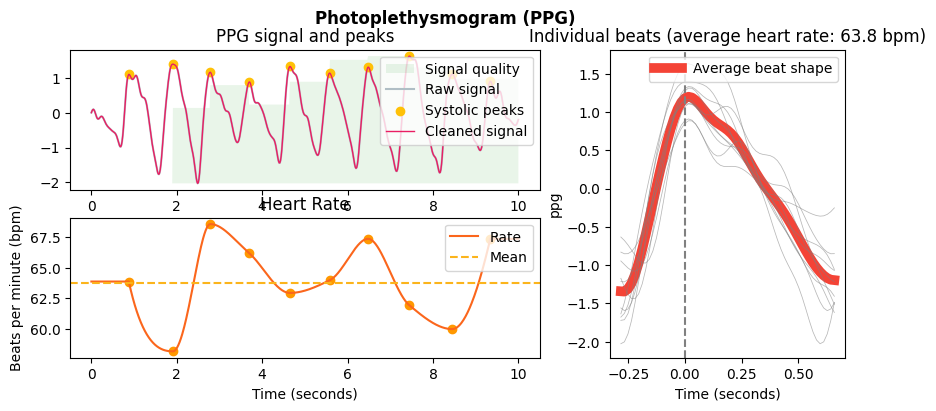

In [ ]:
INDEX = 100

bvp = np.array(list(train['train'][INDEX].values()))[:-1]
bvp = nk.signal_filter(bvp, sampling_rate=FS, lowcut=0.5, highcut=6, method='butterworth', order=4)
signals, info = nk.ppg_process(bvp, sampling_rate=FS, method_cleaning='none')

nk.ppg_plot(signals, info)
fig = plt.gcf()
fig.set_size_inches(10, 4)
plt.show()


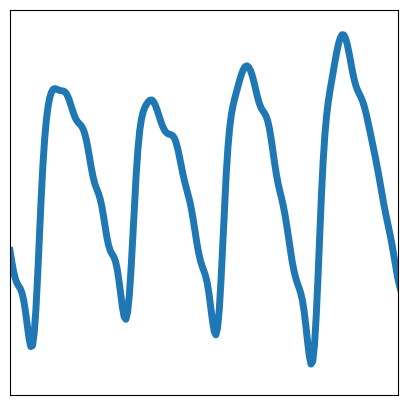

In [ ]:
good = np.array(list(train['train'][2002].values()))[:-1]

plt.figure(figsize=(5,5))
plt.plot(good, linewidth=5)
# plt.xlabel('Time (s)')
# plt.ylabel('PPG')
plt.xlim([0, 3.5*64])
plt.ylim([-2.5,2])
plt.yticks([])
plt.xticks([])
plt.show()

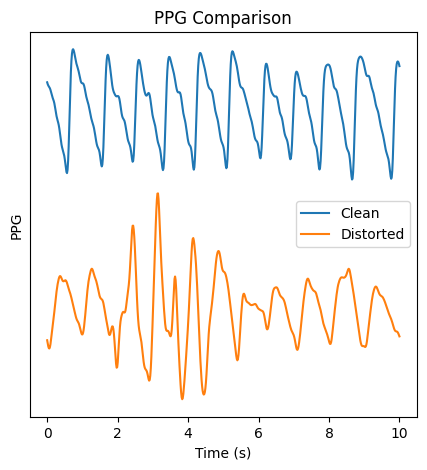

In [ ]:
bad = np.array(list(train['train'][4].values()))[:-1]
good = np.array(list(train['train'][101].values()))[:-1]
t = np.linspace(0, len(bvp)/FS, len(bvp))

plt.figure(figsize=(5,5))
plt.plot(t, good+6, label='Clean')
plt.plot(t, bad, label='Distorted')
plt.plot()
plt.xlabel('Time (s)')
plt.ylabel('PPG')
plt.title('PPG Comparison')
plt.legend(loc='center right')
plt.yticks([])
plt.show()

# Preprocess a specific person

In [ ]:
# DIR_PATH = '/content/drive/MyDrive/ENEE408N/ENEE408N Project/sample of DREAMT dataset'
DIR_PATH = '/data'

SEG_DUR_SEC= 10
FS = 64
SAMPLES_PER_SEG = SEG_DUR_SEC * FS

PPG_LABELED_FILE_TEST = os.path.join(DIR_PATH, 'ppg_labeled_test.csv')
PPG_FILE_TEST_FEAT_EXTR = os.path.join(DIR_PATH, 'ppg_feat_extr_test.csv')


a = np.arange(2, 103+1)
# TEST_IDS = a[(a % 5 == 0) & (a != 60)]
TEST_IDS = a[(a % 5 != 0) & (a != 41)]

FIELDS_OF_INTEREST = ['TIMESTAMP', 'BVP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'Sleep_Stage', 'Obstructive_Apnea', 'Central_Apnea', 'Hypopnea']

In [ ]:
data_files = dict(zip(TEST_IDS, [f'data_64Hz/S{n:03}_whole_df.csv' for n in TEST_IDS]))

dreamt = load_dataset('bsaenz/dreamt', data_files=data_files)

README.md: 0.00B [00:00, ?B/s]

data_64Hz/S002_whole_df.csv:   0%|          | 0.00/140M [00:00<?, ?B/s]

data_64Hz/S003_whole_df.csv:   0%|          | 0.00/142M [00:00<?, ?B/s]

data_64Hz/S004_whole_df.csv:   0%|          | 0.00/140M [00:00<?, ?B/s]

data_64Hz/S006_whole_df.csv:   0%|          | 0.00/149M [00:00<?, ?B/s]

...

Generating 98 split: 0 examples [00:00, ? examples/s]

Generating 99 split: 0 examples [00:00, ? examples/s]

Generating 101 split: 0 examples [00:00, ? examples/s]

Generating 102 split: 0 examples [00:00, ? examples/s]

Generating 103 split: 0 examples [00:00, ? examples/s]

In [ ]:
columns = dreamt[str(TEST_IDS[0])].column_names
remove_cols = [c for c in columns if c not in FIELDS_OF_INTEREST]

def raw_ppg_extraction(ids, wf):
  for id in ids:
    ds = dreamt[str(id)].remove_columns(remove_cols)

    df = ds.to_pandas()

    # Remove any data prior to PSG beginning
    df = df[df['Sleep_Stage'] != 'P']

    # Reindex
    df.reset_index(drop=True, inplace=True)

    # Replace NaN with 0
    df.fillna(0, inplace=True)

    # Consolidate Apnea events into one label
    df['APNEA'] = np.heaviside(df['Obstructive_Apnea'].to_numpy() + df['Central_Apnea'].to_numpy() + df['Hypopnea'].to_numpy(), 0)
    df.drop(columns=['Obstructive_Apnea', 'Central_Apnea', 'Hypopnea'], inplace=True)

    # Now we need to segment into chuncks of 640...
    # Split the signal into SEG_DUR_SEC second intervals (discard any extra data)
    df = df.iloc[:len(df) - len(df) % SAMPLES_PER_SEG]
    chunks = np.split(df, len(df) // SAMPLES_PER_SEG)

    # Save the splits to an individual CSV
    X = np.zeros([len(chunks), len(chunks[0])])
    y = np.zeros(len(chunks))

    print(f'\ntotal number of chunks: {len(chunks)}')
    for i, chunk in enumerate(chunks):
      if i % 100 == 0:
        print(i, end=' ')

      # If any chunk has wake stage, skip it.
      if (chunk['Sleep_Stage'] == 'W').any():
        continue

      # Perform acceleration stuff here
      #
      #

      # Count the number of apnea events in the chunk
      ap_count = chunk['APNEA'].sum()

      # Label as apnea if osa count is nonzero
      X[i] = chunk['BVP'].tolist()
      y[i] = 1 if (ap_count > 0) else 0

    # Since we skipped some chunks, lets remove the rows that are all zero
    row_idx_to_remove = ~np.all(X == 0, axis=1)
    X = X[row_idx_to_remove]
    y = y[row_idx_to_remove]

    # Scale rows and save to CSV
    X_scaled = (X - X.mean(axis=1, keepdims=True))/X.std(axis=1, keepdims=True)
    np.savetxt(wf, np.hstack([X_scaled, y.reshape(-1,1)]), delimiter=",")

print('Processing test samples')
for id in TEST_IDS:
  print(PPG_LABELED_FILE_TEST.split('.')[0]+f'_{id}.csv')
  with open(PPG_LABELED_FILE_TEST.split('.')[0]+f'_{id}.csv', 'w') as wf:
    wf.write(','.join([str(n) for n in range(1,641)] + ['Label'])+'\n')
    raw_ppg_extraction([id], wf)

Processing test samples
/data/ppg_labeled_test_2.csv

total number of chunks: 2229
0 100 200 300 400 500 600 700 800 900 1000 1100 1200 1300 1400 1500 1600 1700 1800 1900 2000 2100 2200 /data/ppg_labeled_test_3.csv

total number of chunks: 2487
0 100 200 300 400 500 600 700 800 900 1000 1100 1200 1300 1400 1500 1600 1700 1800 1900 2000 2100 2200 2300 2400 /data/ppg_labeled_test_4.csv

total number of chunks: 2508
0 100 200 300 400 500 600 700 800 900 1000 1100 1200 1300 1400 1500 1600 1700 1800 1900 2000 2100 2200 2300 2400 2500 /data/ppg_labeled_test_6.csv

total number of chunks: 2529
0 100 200 300 400 500 600 700 800 900 1000 1100 1200 1300 1400 1500 1600 1700 1800 1900 2000 2100 2200 2300 2400 2500 /data/ppg_labeled_test_7.csv

total number of chunks: 2463
0 100 200 300 400 500 600 700 800 900 1000 1100 1200 1300 1400 1500 1600 1700 1800 1900 2000 2100 2200 2300 2400 /data/ppg_labeled_test_8.csv

total number of chunks: 2244
0 100 200 300 400 500 600 700 800 900 1000 1100 1200 1300

In [ ]:
EXTRACTED_HEADER = ['HRV_MeanNN', 'HRV_SDNN', 'HRV_SDANN1', 'HRV_SDNNI1', 'HRV_SDANN2',
  'HRV_SDNNI2', 'HRV_SDANN5', 'HRV_SDNNI5', 'HRV_RMSSD', 'HRV_SDSD',
  'HRV_CVNN', 'HRV_CVSD', 'HRV_MedianNN', 'HRV_MadNN', 'HRV_MCVNN',
  'HRV_IQRNN', 'HRV_SDRMSSD', 'HRV_Prc20NN', 'HRV_Prc80NN', 'HRV_pNN50',
  'HRV_pNN20', 'HRV_MinNN', 'HRV_MaxNN', 'HRV_HTI', 'HRV_TINN', 'HRV_ULF',
  'HRV_VLF', 'HRV_LF', 'HRV_HF', 'HRV_VHF', 'HRV_TP', 'HRV_LFHF',
  'HRV_LFn', 'HRV_HFn', 'HRV_LnHF', 'MaxA', 'MinA', 'MeanA', 'MedianA',
  'SDA', 'RangeA', 'MeanDA', 'SDSA', 'RangeDA', 'MaxDA', 'MinDA', 'MedianDA',
  'MeanHR', 'SDHR', 'MedianHR', 'MinHR', 'MaxHR', 'RangeHR', 'MeanDHR',
  'SDDHR', 'RangeDHR', 'MaxDHR', 'MinDHR', 'MedianDHR',
  'Label'
]

def amplitudes(signals):
  zero = signals['PPG_Clean'].mean()
  peak_vals = (signals['PPG_Clean'][signals['PPG_Peaks'].astype(bool)]).to_numpy() - zero

  out = {}

  out['MaxA'] = np.max(peak_vals)
  out['MinA'] = np.min(peak_vals)
  out['MeanA'] = np.mean(peak_vals)
  out['MedianA'] = np.median(peak_vals)
  out['SDA'] = np.std(peak_vals)
  out['RangeA'] = np.max(peak_vals) - np.min(peak_vals)

  diffs = np.diff(peak_vals)
  out['MeanDA'] = np.mean(diffs)
  out['SDDA'] = np.std(diffs)
  out['RangeDA'] = np.max(diffs) - np.min(diffs)
  out['MaxDA'] = np.max(diffs)
  out['MinDA'] = np.min(diffs)
  out['MedianDA'] = np.median(diffs)

  out = pd.DataFrame.from_dict(out, orient="index").T
  return out

def heartrates(signals):
  hr = signals['PPG_Rate']
  out = {}

  out['MeanHR'] = np.mean(hr)
  out['SDHR'] = np.std(hr)
  out['MedianHR'] = np.median(hr)
  out['MinHR'] = np.min(hr)
  out['MaxHR'] = np.max(hr)
  out['RangeHR'] = np.max(hr) - np.min(hr)

  diffs = np.diff(hr)
  out['MeanDHR'] = np.mean(diffs)
  out['SDDHR'] = np.std(diffs)
  out['RangeDHR'] = np.max(diffs) - np.min(diffs)
  out['MaxDHR'] = np.max(diffs)
  out['MinDHR'] = np.min(diffs)
  out['MedianDHR'] = np.median(diffs)

  out = pd.DataFrame.from_dict(out, orient="index").T
  return out


def feature_extraction(arr):
  # !! arr must be standardized !!
  label = arr[-1]
  bvp = arr[:-1]

  # Missing data
  n_missing = np.sum(np.isnan(bvp))
  if np.sum(np.isnan(bvp)) > 0:
      bvp = nk.signal_fillmissing(bvp, method="both")

  # We need 5 mins of data for power calculations to work, so let's periodic
  # extend so 10 seconds becomes 5 minutes (300 seconds). Then compute powers
  period_extend = np.tile(bvp, 30)

  bvp_filt = nk.signal_filter(bvp, sampling_rate=FS, lowcut=0.5, highcut=6, method='butterworth', order=4)
  try:
    signals_time, info_time = nk.ppg_process(bvp_filt, sampling_rate=FS, method_cleaning='none')
    signals_freq, info_freq = nk.ppg_process(period_extend, sampling_rate=FS, method_cleaning='none')

    time_features = nk.hrv_time(signals_time, sampling_rate=FS).to_numpy()[0]
    freq_features = nk.hrv_frequency(signals_freq, sampling_rate=FS).to_numpy()[0]
    amp_features = amplitudes(signals_time).to_numpy()[0]
    hr_features = heartrates(signals_time).to_numpy()[0]

    # nk.ppg_plot(signals, info)

    all_features = np.hstack([time_features, freq_features, amp_features, hr_features, label])
    np.nan_to_num(all_features, copy=False)
  except KeyboardInterrupt:
    raise
  except Exception as e:
    print('Error occured', e)
    all_features = np.zeros(len(EXTRACTED_HEADER))

  return all_features

cols = test['train'].column_names
def feature_extraction_helper(row):
  arr = np.array([row[c] for c in cols])
  features = feature_extraction(arr)
  return dict(zip(EXTRACTED_HEADER, features))

In [ ]:
for id in TEST_IDS:
  print('processing', id)
  path1 = PPG_LABELED_FILE_TEST.split('.')[0]+f'_{id}.csv'
  test = load_dataset('csv', data_files=path1)

  test_extracted = test.map(feature_extraction_helper, num_proc=12, remove_columns=cols)

  path2 = PPG_FILE_TEST_FEAT_EXTR.split('.')[0]+f'_{id}.csv'
  test_extracted['train'].to_csv(path2, index=False)

processing 2


Map (num_proc=12):   0%|          | 0/1434 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/neurokit2/signal/signal_period.py:83: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(


Error occured cannot convert float NaN to integer


/usr/local/lib/python3.12/dist-packages/neurokit2/signal/signal_period.py:83: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(


...

Creating CSV from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]

processing 103


Generating train split: 0 examples [00:00, ? examples/s]

Map (num_proc=12):   0%|          | 0/2079 [00:00<?, ? examples/s]

Creating CSV from Arrow format:   0%|          | 0/3 [00:00<?, ?ba/s]